# Basics of Information Retrieval

In [2]:
from porter import stem
import matplotlib.pyplot as plt
import numpy as np

# Exo 1

In [3]:
docs = ["the new home has been saled on top forecasts",
         "the home sales rise in july",
         "there is an increase in home sales in july",
         "july encounter a new home sales rise"
         ]
stop_words = ["the", "a", "an", "on", "behind", "under", "there", "in", "on"]

## Q1.1

In [4]:
def count_terms(doc, stop_words=stop_words):
    terms = {}
    for term in doc.split():
        token = stem(term.lower())
        if term not in stop_words:
            if token not in terms:
                terms[token] = 0
            terms[token] += 1
    return terms
    

In [5]:
count_terms(docs[0], stop_words)

{'new': 1, 'home': 1, 'ha': 1, 'been': 1, 'sale': 1, 'top': 1, 'forecast': 1}

## Q1.2

In [6]:
def get_index(docs, stop_words=stop_words):
    index = {}
    for i, doc in enumerate(docs):
        index[i] = count_terms(doc, stop_words)
    return index

def get_inverse_index(docs, stop_words=stop_words):
    inverse_index = {}
    for i, doc in enumerate(docs):
        for term, count in count_terms(doc, stop_words).items():
            if term not in inverse_index:
                inverse_index[term] = {}
            inverse_index[term][i] = count
            
    return inverse_index
        

In [7]:
get_index(docs, stop_words)

{0: {'new': 1,
  'home': 1,
  'ha': 1,
  'been': 1,
  'sale': 1,
  'top': 1,
  'forecast': 1},
 1: {'home': 1, 'sale': 1, 'rise': 1, 'juli': 1},
 2: {'is': 1, 'increas': 1, 'home': 1, 'sale': 1, 'juli': 1},
 3: {'juli': 1, 'encount': 1, 'new': 1, 'home': 1, 'sale': 1, 'rise': 1}}

In [8]:
get_inverse_index(docs, stop_words)

{'new': {0: 1, 3: 1},
 'home': {0: 1, 1: 1, 2: 1, 3: 1},
 'ha': {0: 1},
 'been': {0: 1},
 'sale': {0: 1, 1: 1, 2: 1, 3: 1},
 'top': {0: 1},
 'forecast': {0: 1},
 'rise': {1: 1, 3: 1},
 'juli': {1: 1, 2: 1, 3: 1},
 'is': {2: 1},
 'increas': {2: 1},
 'encount': {3: 1}}

## Q1.3

In [9]:
def get_tf_idf(docs, stop_words=stop_words):
    inverse_index = get_inverse_index(docs, stop_words)
    vocab = list(inverse_index.keys())
    tf = np.zeros((len(docs), len(vocab)))
    df = np.zeros(len(vocab))
    for i_term, term in enumerate(vocab):
        for i_doc in range(len(docs)):
            if i_doc in inverse_index[term]:
                tf[i_doc, i_term] = inverse_index[term][i_doc]
                df[i_term] += 1
    idf = np.log((len(docs) + 1) / (df+1) + 1 )
    tf_idf = tf * idf
    return tf_idf
    

In [10]:
get_tf_idf(docs, stop_words) # TODO: check

array([[0.98082925, 0.69314718, 1.25276297, 1.25276297, 0.69314718,
        1.25276297, 1.25276297, 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.69314718, 0.        , 0.        , 0.69314718,
        0.        , 0.        , 0.98082925, 0.81093022, 0.        ,
        0.        , 0.        ],
       [0.        , 0.69314718, 0.        , 0.        , 0.69314718,
        0.        , 0.        , 0.        , 0.81093022, 1.25276297,
        1.25276297, 0.        ],
       [0.98082925, 0.69314718, 0.        , 0.        , 0.69314718,
        0.        , 0.        , 0.98082925, 0.81093022, 0.        ,
        0.        , 1.25276297]])

# Exercise 2

Boolean model: query is conjunction of terms
Vector approach: binary vectors (query is in {0,1}^|vocab|) or embeddings 

## Q2.1 2.2

In [17]:
query = "home sales top"

In [12]:
def compute_scores_boolean(query, docs):
    '''returns 1 for documents that have all the terms from query, 0 otherwise'''
    scores = np.zeros(len(docs))
    index = get_index(docs)
    query_terms = set(count_terms(query).keys())
    for i_doc, doc_counts in index.items():
        doc_terms = set(doc_counts) 
        if doc_terms >= query_terms:
            scores[i_doc] = 1
    return scores
compute_scores_boolean(query, docs)

array([1., 0., 0., 0.])

## Q2.3

In [13]:
def compute_scores_vectorial(query, docs):
    ''' computes dot product '''
    # TODO: do for tf-idf as well
    scores = np.zeros(len(docs))
    doc_lens = np.zeros(len(docs))
    inverse_index = get_inverse_index(docs)
    query_terms = list(count_terms(query).keys())
    for term in query_terms:
        for i_doc in inverse_index[term]:
            scores[i_doc] += 1

    for term, term_index in inverse_index.items():
        for i_doc in term_index:
            doc_lens[i_doc] += 1 
    scores /= len(query_terms) * doc_lens
    
    return scores
compute_scores_vectorial(query, docs)

array([0.14285714, 0.16666667, 0.13333333, 0.11111111])

In [ ]:
def compute_scores_lm(query, docs, llambda=0.5):
    """Jelineck-Mercer"""
    p_jm = np.ones(len(docs))
    query_terms = list(count_terms(query).keys())
    index = get_index(docs)
    nb_terms = np.sum(
        [count for _, counts in index.items() for count in counts.values()]
    )
    for term in query_terms:
        p_term_doc = np.zeros(len(docs))  # frequency of a term in the doc
        p_term_corpus = np.zeros(len(docs))  # frequency of a term in the corpus
        corpus_term_count = 0
        for i_doc, doc in enumerate(docs):
            term_count = index[i_doc][term] if term in index[i_doc] else 0
            p_term_doc[i_doc] = term_count / np.sum(
                [count for count in index[i_doc].values()]
            )
            corpus_term_count += term_count
            p_term_corpus[i_doc] = corpus_term_count / nb_terms
        p_jm *= (1 - llambda) * p_term_doc + llambda * p_term_corpus
    return p_jm


compute_scores_lm(query, docs, 0.1)

array([0.00235885, 0.00024908, 0.00017043, 0.00012857])

# Exercise 3

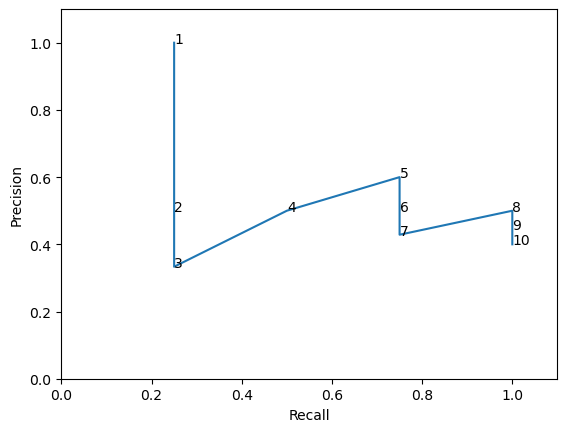

(array([0.25, 0.25, 0.25, 0.5 , 0.75, 0.75, 0.75, 1.  , 1.  , 1.  ]),
 array([1.        , 0.5       , 0.33333333, 0.5       , 0.6       ,
        0.5       , 0.42857143, 0.5       , 0.44444444, 0.4       ]))

In [15]:
def get_pr_curve(retrieved_relevance, plot=True):
    all_t = np.sum(retrieved_relevance)
    precision = np.empty(len(retrieved_relevance))
    recall = np.empty(len(retrieved_relevance))
    for i in range(len(retrieved_relevance)):
        retrieved = retrieved_relevance[:i+1]
        tp = np.sum(retrieved)
        fp = i + 1 - tp
        fn = all_t - tp
        precision[i] = tp / (tp + fp)
        recall[i] = tp / (tp + fn)
        
        if plot: 
            plt.text(recall[i], precision[i], s=str(i+1))
    
    if plot:
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.plot(recall, precision) # , marker="o"
        plt.xlim([0,1.1])
        plt.ylim([0,1.1])
        plt.show()
    return recall, precision
    
get_pr_curve(np.array([1, 0, 0, 1 ,1, 0, 0, 1, 0, 0]))

## Q3.1

Query: top sales
Ranking: [0 3 1 2]
Relevance of retrieved documents: [1 0 0 0]


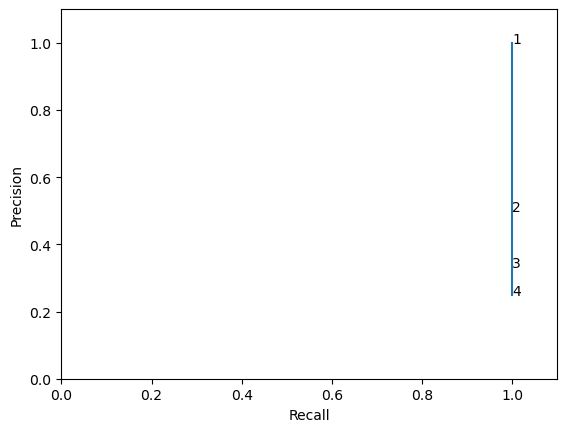

P@2 = 0.5
R@2 = 1.0
F@2 = 0.6666666666666666
Query: sales increase july
Ranking: [2 3 1 0]
Relevance of retrieved documents: [1 0 1 0]


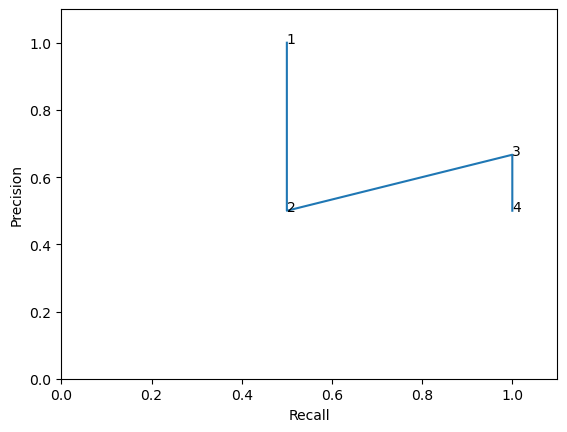

P@2 = 0.5
R@2 = 0.5
F@2 = 0.5
Query: new home
Ranking: [3 0 1 2]
Relevance of retrieved documents: [0 0 0 0]


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_18871/3991321136.py:11: RuntimeWarning: invalid value encountered in scalar divide
  recall[i] = tp / (tp + fn)


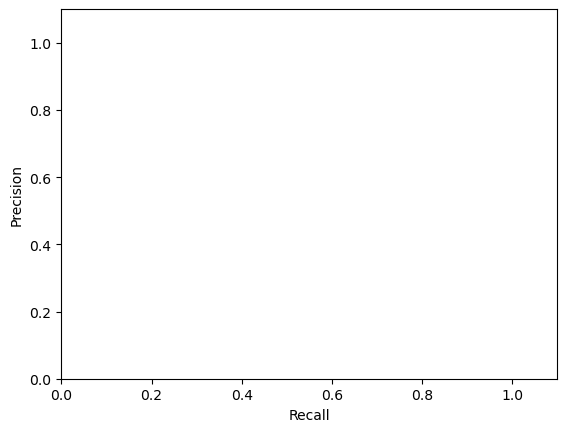

P@2 = 0.0
R@2 = nan
F@2 = nan


/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_18871/1320290918.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  print("F@2 =", 2  / (1/ recall[1] + 1/precision[1]) )


In [16]:
queries_relevance = {
    "top sales": [0], 
    "sales increase july": [1,2], 
    "new home": []}
for query, relevant_docs in queries_relevance.items():
    print("Query:", query)
    scores = compute_scores_lm(query, docs, 0.1) # compute_scores_vectorial(query, docs) 
    ranking = scores.argsort()[::-1]
    print("Ranking:", ranking)
    retrieved_relevance = np.array([ int(i_doc in relevant_docs) for i_doc in ranking])
    print("Relevance of retrieved documents:", retrieved_relevance)
    recall, precision = get_pr_curve(retrieved_relevance)
    print("P@2 =", precision[1])
    print("R@2 =", recall[1])
    print("F@2 =", 2  / (1/ recall[1] + 1/precision[1]) ) 
    

# PR Curve